In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_breast_cancer

%matplotlib inline


# 1. Carrega o dataset

In [2]:
cancer_dataset = load_breast_cancer()
data = pd.DataFrame(cancer_dataset.data, columns=cancer_dataset.feature_names)
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 2. Informações gerais sobre o dataset

In [3]:
print(f"\nSHAPE:")
print(f"   - Linhas: {data.shape[0]}")
print(f"   - Colunas: {data.shape[1]}")

print(f"\nCLASSES:")
print(f"   - {cancer_dataset.target_names[0]}: {(cancer_dataset.target == 0).sum()} amostras")
print(f"   - {cancer_dataset.target_names[1]}: {(cancer_dataset.target == 1).sum()} amostras")

print(f"\nFEATURES:")
for i, feature in enumerate(data.columns, 1):
    print(f"   {i:2d}. {feature}")



SHAPE:
   - Linhas: 569
   - Colunas: 30

CLASSES:
   - malignant: 212 amostras
   - benign: 357 amostras

FEATURES:
    1. mean radius
    2. mean texture
    3. mean perimeter
    4. mean area
    5. mean smoothness
    6. mean compactness
    7. mean concavity
    8. mean concave points
    9. mean symmetry
   10. mean fractal dimension
   11. radius error
   12. texture error
   13. perimeter error
   14. area error
   15. smoothness error
   16. compactness error
   17. concavity error
   18. concave points error
   19. symmetry error
   20. fractal dimension error
   21. worst radius
   22. worst texture
   23. worst perimeter
   24. worst area
   25. worst smoothness
   26. worst compactness
   27. worst concavity
   28. worst concave points
   29. worst symmetry
   30. worst fractal dimension


# 3. Gráfico

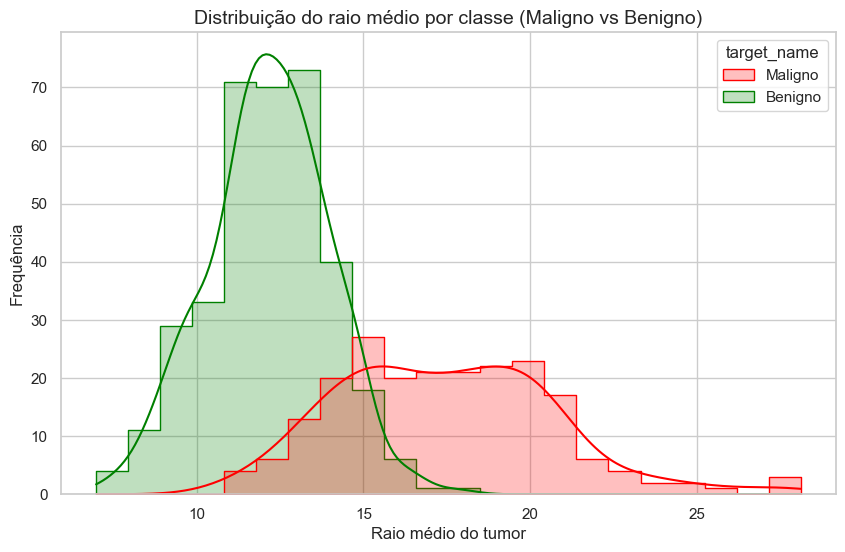

In [4]:
df = data.copy()
df['target'] = cancer_dataset.target

df['target_name'] = df['target'].map({0: 'Maligno', 1: 'Benigno'})

sns.set_theme(style="whitegrid")
color = {'Maligno': 'red', 'Benigno': 'green'}

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='mean radius', hue='target_name', kde=True, element="step", palette=color)

plt.title('Distribuição do raio médio por classe (Maligno vs Benigno)', fontsize=14)
plt.xlabel('Raio médio do tumor', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

# Mostra o gráfico
plt.show()

# Pré-processamento
Essa etapa é necessária porque, se alguma coluna tiver valores muito diferentes das outras, isso pode gerar uma distância matemática muito grande. O computador pode acabar achando que uma coluna com números maiores é mais importante do que uma com números menores.

Fazendo uma analogia com o dataset: a coluna mean area tem valores que passam de 1.000, enquanto a coluna mean concavity tem valores decimais como 0.1 e 0.2. O StandardScaler serve para colocar as colunas na mesma escala.

In [5]:
colunas_selecionadas = ['mean radius', 'mean texture', 'mean area', 'mean concavity']
X = df[colunas_selecionadas]
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=colunas_selecionadas)
X_scaled_df['target'] = y.values


# 5. Treinamento

In [11]:
# k - quanto menor o k, mais complexo o modelo, se houver um dado errado, o modelo vai seguir esse erro sempre 
# k - quanto maior o k, mais geral o modelo, ele ignora as variações e foca na votação da maioria, ignorando as características reais
# k - é o que faz a acurácia variar 
modelo = KNeighborsClassifier(n_neighbors=11)
modelo.fit(X_scaled, y)

print(f"Modelo treinado com dados normalizados")
print(X_scaled_df.round(2))

y_pred = modelo.predict(X_scaled)

acuracia = accuracy_score(y, y_pred)
print(f"Acurácia do modelo com k={modelo.n_neighbors}: {acuracia:.2%}")

Modelo treinado com dados normalizados
     mean radius  mean texture  mean area  mean concavity  target
0           1.10         -2.07       0.98            2.65       0
1           1.83         -0.35       1.91           -0.02       0
2           1.58          0.46       1.56            1.36       0
3          -0.77          0.25      -0.76            1.92       0
4           1.75         -1.15       1.83            1.37       0
..           ...           ...        ...             ...     ...
564         2.11          0.72       2.34            1.95       0
565         1.70          2.09       1.72            0.69       0
566         0.70          2.05       0.58            0.05       0
567         1.84          2.34       1.74            3.30       0
568        -1.81          1.22      -1.35           -1.11       1

[569 rows x 5 columns]
Acurácia do modelo com k=11: 93.85%


# 6. Gráfico de acurária

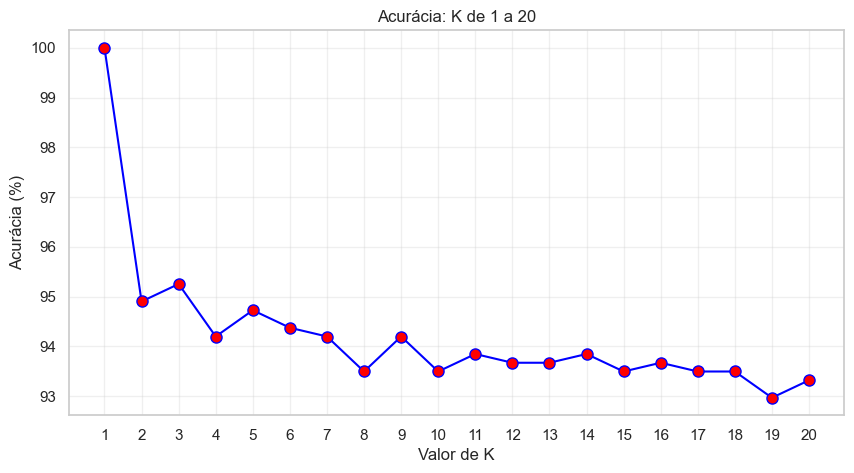

In [14]:
k_valores = list(range(1, 21)) 
lista_acuracias = []

for k in k_valores:
    knn_teste = KNeighborsClassifier(n_neighbors=k)
    knn_teste.fit(X_scaled, y)
    
    predicao = knn_teste.predict(X_scaled)
    acuracia = accuracy_score(y, predicao)
    lista_acuracias.append(acuracia * 100)

plt.figure(figsize=(10, 5))
plt.plot(k_valores, lista_acuracias, color='blue', linestyle='-', marker='o', markerfacecolor='red', markersize=8)

plt.title('Acurácia: K de 1 a 20')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia (%)')
plt.xticks(k_valores) 
plt.grid(True, alpha=0.3)

plt.show()

# 7. Modelo final

Analisando o gráfico, optei pelo $K = 11$ porque, entre os valores 11 e 14, a acurácia se mantém estável. Como o problema possui duas classes, maligno e benigno, filtrei apenas os números ímpares dessa região para evitar empates na votação, sendo que o 11 apresentou uma acurácia superior à do 13, tornando-se a escolha ideal e mais segura para o modelo final.

In [12]:
X = df[['mean radius', 'mean texture', 'mean area', 'mean concavity']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Retorno do train_test_split:")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")
print()

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train) 
X_test_s = scaler.transform(X_test)       

modelo_final = KNeighborsClassifier(n_neighbors=11)
modelo_final.fit(X_train_s, y_train)

y_prev = modelo_final.predict(X_test_s)

print(classification_report(
    y_test, 
    y_prev, 
    target_names=["Maligno", "Benigno"]
))

Retorno do train_test_split:
X_train: (426, 4) | X_test: (143, 4)
y_train: (426,) | y_test: (143,)

              precision    recall  f1-score   support

     Maligno       0.89      0.91      0.90        53
     Benigno       0.94      0.93      0.94        90

    accuracy                           0.92       143
   macro avg       0.92      0.92      0.92       143
weighted avg       0.92      0.92      0.92       143

